# 04 -- Dashboard & Predictions temps reel
## VelibMMM -- Carte interactive des stations Velib

**Objectif :** utiliser le modele bayesien entraine pour generer des predictions
de disponibilite a t+30min sur toutes les stations, avec intervalles de credibilite.

**Livrables :**
- Carte Folium interactive : stations colorees par fill_rate predit
- Alertes stations critiques (fill_rate_t30 < 0.10)
- IC 94% bayesien sur chaque prediction
- Rapport CSV exportable

---
### Plan
1. Chargement du modele et du dernier snapshot
2. Preparation des features pour la prediction
3. Predictions bayesiennes avec IC
4. Carte Folium interactive
5. Alertes stations critiques
6. Export rapport

## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.spatial import cKDTree
import json
import warnings
warnings.filterwarnings('ignore')

ROOT     = Path('..').resolve()
PROC_DIR = ROOT / 'data' / 'processed'
MOD_DIR  = ROOT / 'outputs' / 'models'
FIG_DIR  = ROOT / 'outputs' / 'figures'
REP_DIR  = ROOT / 'outputs' / 'reports'
REP_DIR.mkdir(parents=True, exist_ok=True)

# Chargement artefacts modele
artifacts = json.loads((MOD_DIR / 'velib_model_artifacts.json').read_text())
config    = json.loads((PROC_DIR / 'features_config.json').read_text())

ALPHA_MEAN     = artifacts['alpha_mean']
BETA_MEAN      = np.array(artifacts['beta_mean'])
KAPPA_MEAN     = artifacts['kappa_mean']
MODEL_FEATURES = artifacts['model_features']
CONTINUOUS     = artifacts['continuous_features']
NORM_MEANS     = pd.Series(artifacts['norm_means'])
NORM_STDS      = pd.Series(artifacts['norm_stds'])

print('[OK] Modele charge')
print(f'Features : {MODEL_FEATURES}')
print(f'alpha    : {ALPHA_MEAN:.4f}')
print(f'beta     : {[round(b,4) for b in BETA_MEAN]}')
print(f'kappa    : {KAPPA_MEAN:.2f}')
print(f'\nMetriques entrainement :')
for k, v in artifacts['metrics'].items():
    print(f'  {k} : {v:.4f}')

[OK] Modele charge
Features : ['fill_rate', 'adstock_drain', 'drainage', 'hour_sin', 'hour_cos', 'is_rush', 'neighbor_fr_mean']
alpha    : -0.7724
beta     : [np.float64(1.121), np.float64(-0.0353), np.float64(0.0151), np.float64(-0.0077), np.float64(0.023), np.float64(0.0369), np.float64(0.0401)]
kappa    : 29.34

Metriques entrainement :
  mae : 0.0427
  rmse : 0.0653
  r2 : 0.9191
  r : 0.9593


## 1. Chargement du dernier snapshot

On charge le dataset features complet et on prend le **dernier timestamp disponible**
comme snapshot 'temps reel' pour les predictions.

In [2]:
# Chargement du dataset features
df_feat = pd.read_parquet(PROC_DIR / 'velib_features.parquet')
df_feat['ts_utc'] = pd.to_datetime(df_feat['ts_utc'], utc=True)

# Dernier timestamp disponible
ts_last = df_feat['ts_utc'].max()
df_last = df_feat[df_feat['ts_utc'] == ts_last].copy()

print(f'Dataset features total : {df_feat.shape}')
print(f'Dernier snapshot       : {ts_last}')
print(f'Stations dans snapshot : {len(df_last)}')
print(f'Colonnes disponibles   : {df_last.columns.tolist()}')

Dataset features total : (796287, 25)
Dernier snapshot       : 2021-04-09 14:25:00+00:00
Stations dans snapshot : 1390
Colonnes disponibles   : ['station_id', 'fill_rate', 'fill_rate_t30', 'ts_utc', 'name_x', 'hour', 'day_of_week', 'is_rush', 'is_weekend', 'is_night', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'time_of_day', 'drainage', 'adstock_drain', 'surplus', 'lat', 'lon', 'capacity', 'available_mechanical', 'available_ebike', 'name_y', 'neighbor_fr_mean']


## 2. Preparation des features pour la prediction

On applique exactement les memes transformations que pendant l'entrainement :
normalisation des features continues avec les stats de l'entrainement.

In [3]:
# Verifier que toutes les features sont presentes
missing = [f for f in MODEL_FEATURES if f not in df_last.columns]
if missing:
    print(f'[WARN] Features manquantes : {missing}')
    print('       On les remplace par 0')
    for f in missing:
        df_last[f] = 0.0

# Extraire X
X_pred = df_last[MODEL_FEATURES].copy()

# Normalisation avec les stats d entrainement
for col in CONTINUOUS:
    if col in X_pred.columns and col in NORM_MEANS.index:
        X_pred[col] = (X_pred[col] - NORM_MEANS[col]) / NORM_STDS[col]

# Remplir les NaN restants
X_pred = X_pred.fillna(0.0)
X_arr = X_pred.values.astype(np.float64)

print(f'X_pred shape : {X_arr.shape}')
print(f'NaN restants : {np.isnan(X_arr).sum()}')
print(f'Features     : {MODEL_FEATURES}')

X_pred shape : (1390, 7)
NaN restants : 0
Features     : ['fill_rate', 'adstock_drain', 'drainage', 'hour_sin', 'hour_cos', 'is_rush', 'neighbor_fr_mean']


## 3. Predictions bayesiennes avec IC 94%

On utilise la trace MCMC pour generer une **distribution de predictions**
pour chaque station. Cela donne non pas un seul chiffre mais un intervalle :

```
Pour chaque echantillon MCMC (alpha_s, beta_s) :
    mu_s = sigmoid(alpha_s + X @ beta_s)
Prediction finale :
    mean = moyenne des mu_s
    IC94 = [percentile 3%, percentile 97%]
```

In [4]:
# Chargement de la trace pour l'incertitude
try:
    import arviz as az
    trace = az.from_netcdf(str(MOD_DIR / 'velib_bayes_trace.nc'))
    beta_samples  = trace.posterior['beta'].values.reshape(-1, len(MODEL_FEATURES))
    alpha_samples = trace.posterior['alpha'].values.flatten()
    N_POST = min(500, len(alpha_samples))
    beta_samples  = beta_samples[:N_POST]
    alpha_samples = alpha_samples[:N_POST]
    HAS_TRACE = True
    print(f'[OK] Trace chargee : {N_POST} echantillons posterieurs')
except Exception as e:
    print(f'[WARN] Trace non disponible ({e})')
    print('       Utilisation des moyennes posterieures uniquement')
    HAS_TRACE = False

# Prediction point (moyenne posterieure)
logit_mu = ALPHA_MEAN + X_arr @ BETA_MEAN
mu_pred  = 1 / (1 + np.exp(-logit_mu))

if HAS_TRACE:
    # Distribution des predictions
    logit_mu_post = alpha_samples[:, None] + (beta_samples @ X_arr.T)
    mu_post = 1 / (1 + np.exp(-logit_mu_post))
    pred_lo = np.percentile(mu_post, 3,  axis=0)
    pred_hi = np.percentile(mu_post, 97, axis=0)
    pred_std = mu_post.std(axis=0)
else:
    pred_lo  = mu_pred - 0.05
    pred_hi  = mu_pred + 0.05
    pred_std = np.full_like(mu_pred, 0.05)

# Assemblage des resultats
id_col = 'station_id' if 'station_id' in df_last.columns else 'name'

df_pred = df_last[[id_col, 'lat', 'lon', 'fill_rate']].copy()
df_pred = df_pred.rename(columns={id_col: 'station_id'})
df_pred['fill_rate_pred']   = mu_pred.clip(0, 1)
df_pred['fill_rate_pred_lo'] = pred_lo.clip(0, 1)
df_pred['fill_rate_pred_hi'] = pred_hi.clip(0, 1)
df_pred['pred_std']         = pred_std
df_pred['ts_snapshot']      = ts_last
df_pred['alerte_critique']  = df_pred['fill_rate_pred'] < 0.10

print(f'[OK] Predictions generees : {len(df_pred)} stations')
print(f'\nDistribution fill_rate_pred :')
print(df_pred['fill_rate_pred'].describe().round(3))
print(f'\nStations critiques (pred < 0.10) : {df_pred["alerte_critique"].sum()}')
df_pred.head(5)

[OK] Trace chargee : 500 echantillons posterieurs
[OK] Predictions generees : 1390 stations

Distribution fill_rate_pred :
count    1390.000
mean        0.316
std         0.242
min         0.062
25%         0.120
50%         0.214
75%         0.467
max         0.922
Name: fill_rate_pred, dtype: float64

Stations critiques (pred < 0.10) : 218


,station_id,lat,lon,fill_rate,fill_rate_pred,fill_rate_pred_lo,fill_rate_pred_hi,pred_std,ts_snapshot,alerte_critique
794897,Jean Bleuzen - Square du 11 Novembre,48.82326,2.29652,0.020408,0.078908,0.077713,0.080471,0.000757,2021-04-09 14:25:00+00:00,True
794898,Place Léon Gambetta,48.81461,2.40293,0.423077,0.400726,0.397206,0.404525,0.002004,2021-04-09 14:25:00+00:00,False
794899,11 Novembre 1918 - 8 Mai 1945,48.80890,2.53824,0.055556,0.103929,0.101706,0.106220,0.001185,2021-04-09 14:25:00+00:00,False
794900,18 juin 1940 - Buzenval,48.86881,2.18543,0.240000,0.204642,0.202067,0.207479,0.001482,2021-04-09 14:25:00+00:00,False
794901,Abbeville - Faubourg Poissonnière,48.87922,2.34915,0.142857,0.137143,0.135060,0.140050,0.001320,2021-04-09 14:25:00+00:00,False


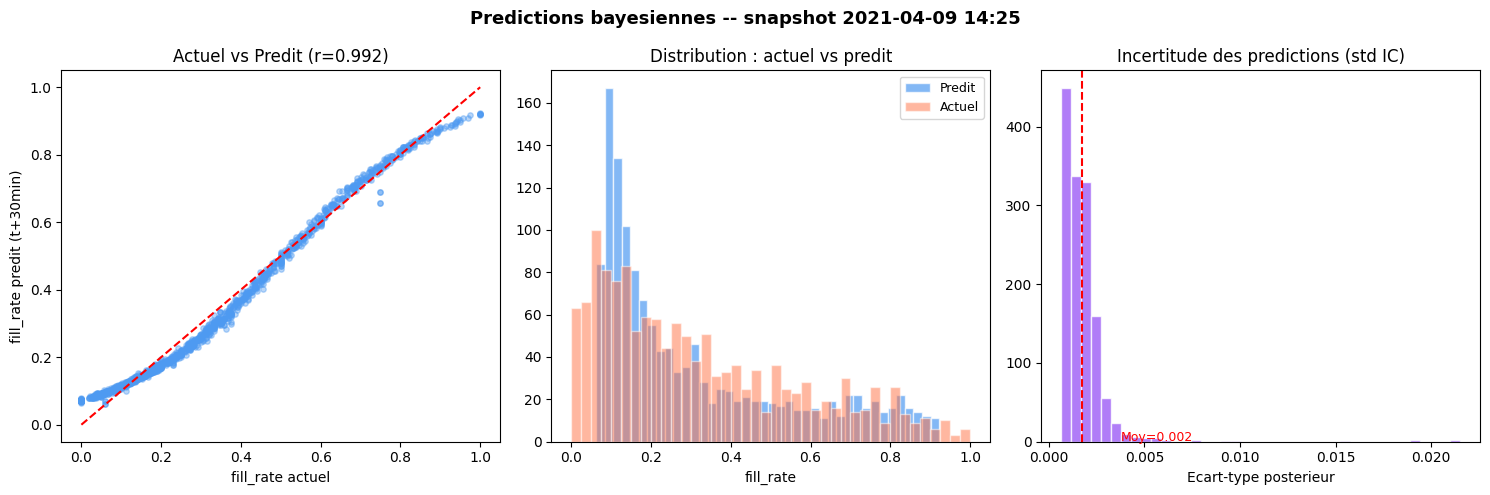

[OK] Figure sauvegardee


In [5]:
# Validation : predit vs actuel sur le snapshot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Predictions bayesiennes -- snapshot {str(ts_last)[:16]}',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(df_pred['fill_rate'], df_pred['fill_rate_pred'],
           alpha=0.4, s=15, color='#4E9AF1')
ax.plot([0,1],[0,1], color='red', linewidth=1.5, linestyle='--')
r = df_pred['fill_rate'].corr(df_pred['fill_rate_pred'])
ax.set_xlabel('fill_rate actuel')
ax.set_ylabel('fill_rate predit (t+30min)')
ax.set_title(f'Actuel vs Predit (r={r:.3f})')

ax2 = axes[1]
ax2.hist(df_pred['fill_rate_pred'], bins=40, color='#4E9AF1',
         alpha=0.7, edgecolor='white', label='Predit')
ax2.hist(df_pred['fill_rate'], bins=40, color='#FF7043',
         alpha=0.5, edgecolor='white', label='Actuel')
ax2.set_xlabel('fill_rate')
ax2.set_title('Distribution : actuel vs predit')
ax2.legend(fontsize=9)

ax3 = axes[2]
ax3.hist(df_pred['pred_std'], bins=40, color='#9C5CF5', alpha=0.8, edgecolor='white')
ax3.set_xlabel('Ecart-type posterieur')
ax3.set_title('Incertitude des predictions (std IC)')
mean_std = df_pred['pred_std'].mean()
ax3.axvline(x=mean_std, color='red', linestyle='--')
ax3.annotate(f'Moy={mean_std:.3f}', xy=(mean_std+0.002, 1), fontsize=9, color='red')

plt.tight_layout()
plt.savefig(str(FIG_DIR / '04_predictions_validation.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')

## 4. Carte Folium interactive

Chaque station est representee par un cercle colore selon le **fill_rate predit a t+30min** :

- Rouge fonce : station presque vide (< 10%) -- alerte critique
- Orange : faible disponibilite (10-30%)
- Jaune : disponibilite moyenne (30-50%)
- Vert clair : bonne disponibilite (50-70%)
- Vert fonce : station bien remplie (> 70%)

Le popup affiche : fill_rate actuel, fill_rate predit, IC 94%, alerte.

In [6]:
try:
    import folium
    from folium.plugins import MarkerCluster

    m = folium.Map(
        location=[48.8566, 2.3522],
        zoom_start=13,
        tiles='CartoDB positron'
    )

    def color_pred(fr):
        if fr < 0.10:  return '#CC0000'
        elif fr < 0.25: return '#FF6600'
        elif fr < 0.40: return '#FFAA00'
        elif fr < 0.60: return '#FFD700'
        elif fr < 0.75: return '#88CC44'
        else:           return '#22AA22'

    n_plotted = 0
    for _, row in df_pred.iterrows():
        if pd.isna(row['lat']) or pd.isna(row['lon']):
            continue

        fr_pred = row['fill_rate_pred']
        fr_curr = row['fill_rate']
        lo      = row['fill_rate_pred_lo']
        hi      = row['fill_rate_pred_hi']
        alerte  = row['alerte_critique']

        # Taille du cercle proportionnelle a l'incertitude
        radius = 4 + row['pred_std'] * 20

        popup_html = (
            f'<b>{row["station_id"]}</b><br>'
            f'<hr style="margin:3px">'
            f'fill_rate actuel : <b>{fr_curr:.1%}</b><br>'
            f'fill_rate predit (t+30) : <b>{fr_pred:.1%}</b><br>'
            f'IC 94% : [{lo:.1%}, {hi:.1%}]<br>'
            f'Snapshot : {str(row["ts_snapshot"])[:16]}<br>'
            + ('<b style="color:red">⚠ ALERTE : station presque vide !</b>' if alerte else '')
        )

        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=radius,
            color='#CC0000' if alerte else color_pred(fr_pred),
            fill=True,
            fill_color=color_pred(fr_pred),
            fill_opacity=0.80,
            weight=2 if alerte else 0.5,
            popup=folium.Popup(popup_html, max_width=250)
        ).add_to(m)
        n_plotted += 1

    # Legende
    legend = (
        '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;'
        'background:white;padding:12px;border-radius:8px;'
        'border:1px solid #ccc;font-size:12px;min-width:180px;">'
        '<b>fill_rate predit (t+30min)</b><br><br>'
        '<span style="color:#CC0000">&#9679;</span> &lt; 10% -- ALERTE<br>'
        '<span style="color:#FF6600">&#9679;</span> 10 - 25% -- Faible<br>'
        '<span style="color:#FFAA00">&#9679;</span> 25 - 40% -- Modere<br>'
        '<span style="color:#FFD700">&#9679;</span> 40 - 60% -- Moyen<br>'
        '<span style="color:#88CC44">&#9679;</span> 60 - 75% -- Bon<br>'
        '<span style="color:#22AA22">&#9679;</span> &gt; 75% -- Excellent<br>'
        '<br><i>Taille &#x221d; incertitude IC</i>'
        '</div>'
    )
    m.get_root().html.add_child(folium.Element(legend))

    # Titre
    titre = (
        f'<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);'
        f'z-index:1000;background:rgba(26,58,92,0.9);color:white;'
        f'padding:8px 16px;border-radius:6px;font-size:13px;font-weight:bold;">'
        f'VelibMMM -- Predictions t+30min -- {str(ts_last)[:16]} UTC'
        f'</div>'
    )
    m.get_root().html.add_child(folium.Element(titre))

    map_path = str(FIG_DIR / '04_carte_predictions.html')
    m.save(map_path)
    print(f'[OK] Carte sauvegardee : outputs/figures/04_carte_predictions.html')
    print(f'     {n_plotted} stations cartographiees')
    print(f'     {df_pred["alerte_critique"].sum()} alertes critiques (rouge)')
    m

except ImportError:
    print('[WARN] folium non installe -- pip install folium')

[OK] Carte sauvegardee : outputs/figures/04_carte_predictions.html
     1390 stations cartographiees
     218 alertes critiques (rouge)


## 5. Alertes stations critiques

Les stations avec `fill_rate_pred < 0.10` sont les candidates
prioritaires pour un rebalancement. On les affiche avec leur IC bayesien
pour quantifier la certitude de l'alerte.

=== ALERTES STATIONS CRITIQUES ===
Snapshot : 2021-04-09 14:25 UTC
Nombre   : 218 stations / 1390 total (15.7%)

Station                                         Actuel   Predit   IC94 lo   IC94 hi Certitude
-------------------------------------------------------------------------------------
Place de l'Europe                                 5.9%     6.2%      5.3%      7.3% TRES HAUTE
Place de l'Europe                                 5.9%     6.2%      5.3%      7.3% TRES HAUTE
Demi-Lune - Aristide Briand                       0.0%     6.6%      6.4%      6.8% TRES HAUTE
Dunkerque - Trudaine                              0.0%     6.6%      6.4%      7.0% TRES HAUTE
Belleville -  Pré Saint-Gervais                   0.0%     6.8%      6.6%      7.0% TRES HAUTE
Jardin de l'Hospice Debrousse                     0.0%     6.9%      6.8%      7.1% TRES HAUTE
Général Leclerc - Bièvre                          0.0%     7.0%      6.7%      7.3% TRES HAUTE
Pyrénées - Ménilmontant                   

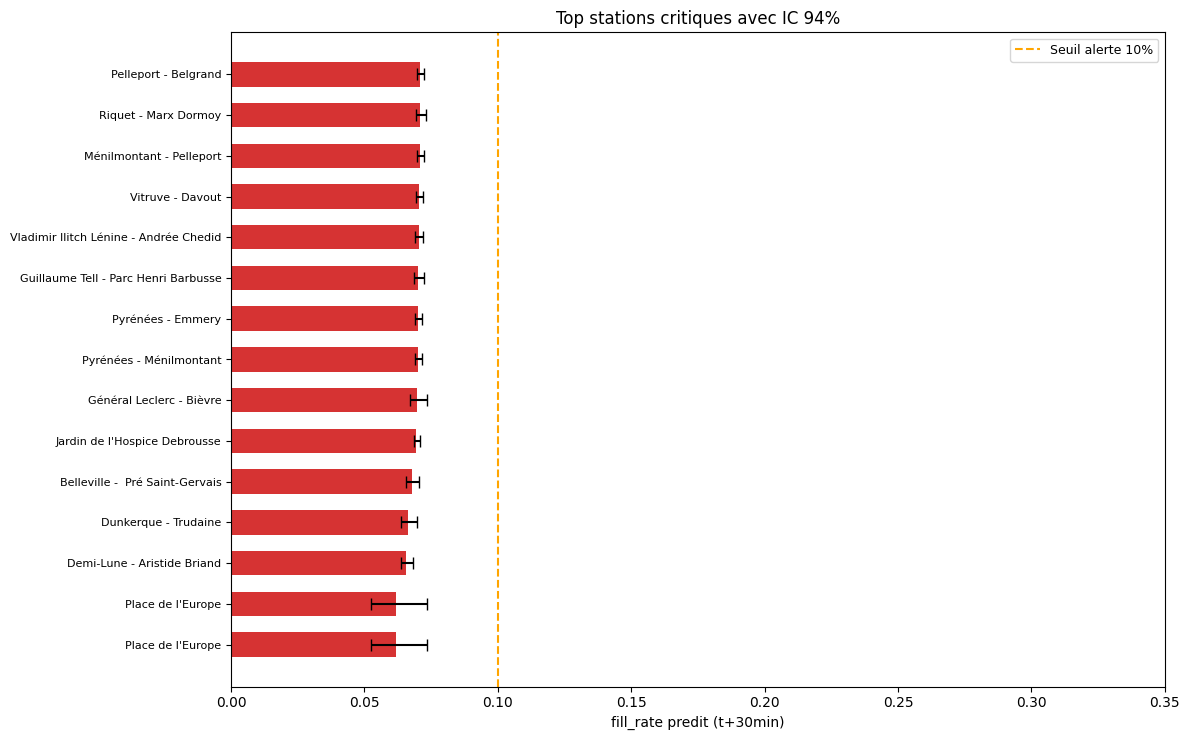

[OK] Figure sauvegardee


In [7]:
alertes = df_pred[df_pred['alerte_critique']].sort_values('fill_rate_pred').copy()

print(f'=== ALERTES STATIONS CRITIQUES ===')
print(f'Snapshot : {str(ts_last)[:16]} UTC')
print(f'Nombre   : {len(alertes)} stations / {len(df_pred)} total ({len(alertes)/len(df_pred)*100:.1f}%)')
print()

if len(alertes) > 0:
    print(f'{"Station":<45} {"Actuel":>8} {"Predit":>8} {"IC94 lo":>9} {"IC94 hi":>9} {"Certitude"}')
    print('-' * 85)
    for _, row in alertes.head(20).iterrows():
        certitude = 'TRES HAUTE' if row['fill_rate_pred_hi'] < 0.15 else 'HAUTE' if row['fill_rate_pred_hi'] < 0.25 else 'MODEREE'
        nom = str(row['station_id'])[:43]
        print(f'{nom:<45} {row["fill_rate"]:>8.1%} {row["fill_rate_pred"]:>8.1%} '
              f'{row["fill_rate_pred_lo"]:>9.1%} {row["fill_rate_pred_hi"]:>9.1%} {certitude}')
else:
    print('Aucune station critique detectee sur ce snapshot.')

# Visualisation alertes
if len(alertes) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(alertes.head(15))*0.5)))
    alertes_plot = alertes.head(15).copy()
    y_pos = range(len(alertes_plot))
    noms  = [str(s)[:40] for s in alertes_plot['station_id']]

    ax.barh(y_pos, alertes_plot['fill_rate_pred'], color='#CC0000', alpha=0.8, height=0.6)
    ax.errorbar(
        alertes_plot['fill_rate_pred'].values, list(y_pos),
        xerr=[alertes_plot['fill_rate_pred'].values - alertes_plot['fill_rate_pred_lo'].values,
              alertes_plot['fill_rate_pred_hi'].values - alertes_plot['fill_rate_pred'].values],
        fmt='none', color='black', capsize=4, linewidth=1.5
    )
    ax.axvline(x=0.10, color='orange', linestyle='--', linewidth=1.5, label='Seuil alerte 10%')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(noms, fontsize=8)
    ax.set_xlabel('fill_rate predit (t+30min)')
    ax.set_title('Top stations critiques avec IC 94%')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 0.35)

    plt.tight_layout()
    plt.savefig(str(FIG_DIR / '04_alertes_critiques.png'), bbox_inches='tight', dpi=150)
    plt.show()
    print('[OK] Figure sauvegardee')

## 6. Export du rapport

In [9]:
# Export CSV rapport complet
rapport = df_pred[[
    'station_id','lat','lon',
    'fill_rate','fill_rate_pred','fill_rate_pred_lo','fill_rate_pred_hi',
    'pred_std','alerte_critique','ts_snapshot'
]].copy()
rapport['fill_rate_pct']     = (rapport['fill_rate'] * 100).round(1)
rapport['fill_rate_pred_pct'] = (rapport['fill_rate_pred'] * 100).round(1)
rapport['ic_lo_pct']         = (rapport['fill_rate_pred_lo'] * 100).round(1)
rapport['ic_hi_pct']         = (rapport['fill_rate_pred_hi'] * 100).round(1)

rapport_path = REP_DIR / 'predictions_t30.csv'
rapport.to_csv(rapport_path, index=False)

print(f'[OK] Rapport CSV : {rapport_path}')
print(f'     {len(rapport)} stations')
print(f'     {rapport["alerte_critique"].sum()} alertes critiques')
print()
print('=== RESUME EXECUTIF ===')
print(f'Snapshot analyse    : {str(ts_last)[:16]} UTC')
print(f'Stations predites   : {len(df_pred)}')
fr_mean_pred = df_pred["fill_rate_pred"].mean()
fr_std_pred  = df_pred["fill_rate_pred"].std()
print(f'fill_rate moyen     : {fr_mean_pred:.1%} (std={fr_std_pred:.1%})')
n_crit = df_pred["alerte_critique"].sum()
pct_crit = n_crit/len(df_pred)*100
print(f'Stations critiques  : {n_crit} ({pct_crit:.1f}%)')
n_good = (df_pred['fill_rate_pred'] > 0.60).sum()
pct_good = n_good/len(df_pred)*100
print(f'Stations bien remplies (>60%) : {n_good} ({pct_good:.1f}%)')
ic_width = (df_pred['fill_rate_pred_hi'] - df_pred['fill_rate_pred_lo']).mean()
print(f'IC 94% moyen (largeur) : {ic_width:.1%}')
print()
print('FICHIERS PRODUITS')
print(f'  Carte interactive : outputs/figures/04_carte_predictions.html')
print(f'  Rapport CSV       : outputs/reports/predictions_t30.csv')
print(f'  Graphiques        : outputs/figures/04_*.png')

[OK] Rapport CSV : /Users/souhail/projets-ml/Velib-analytics/outputs/reports/predictions_t30.csv
     1390 stations
     218 alertes critiques

=== RESUME EXECUTIF ===
Snapshot analyse    : 2021-04-09 14:25 UTC
Stations predites   : 1390
fill_rate moyen     : 31.6% (std=24.2%)
Stations critiques  : 218 (15.7%)
Stations bien remplies (>60%) : 242 (17.4%)
IC 94% moyen (largeur) : 0.7%

FICHIERS PRODUITS
  Carte interactive : outputs/figures/04_carte_predictions.html
  Rapport CSV       : outputs/reports/predictions_t30.csv
  Graphiques        : outputs/figures/04_*.png
